In [1]:
import pandas as pd

df = pd.read_csv('WA_Marketing-Campaign.csv')
print(df.head())

   MarketID MarketSize  LocationID  AgeOfStore  Promotion  week  \
0         1     Medium           1           4          3     1   
1         1     Medium           1           4          3     2   
2         1     Medium           1           4          3     3   
3         1     Medium           1           4          3     4   
4         1     Medium           2           5          2     1   

   SalesInThousands  
0             33.73  
1             35.67  
2             29.03  
3             39.25  
4             27.81  


In [2]:
df.columns = df.columns.str.lower()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   marketid          548 non-null    int64  
 1   marketsize        548 non-null    object 
 2   locationid        548 non-null    int64  
 3   ageofstore        548 non-null    int64  
 4   promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   salesinthousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [4]:
df['promotion'].unique()


array([3, 2, 1])

In [5]:
stores_count_flat = df.groupby(['promotion', 'marketsize'])['locationid'].nunique().reset_index()
print(stores_count_flat)

   promotion marketsize  locationid
0          1      Large          14
1          1     Medium          24
2          1      Small           5
3          2      Large          16
4          2     Medium          27
5          2      Small           4
6          3      Large          12
7          3     Medium          29
8          3      Small           6


относительно одинаковое количество магазинов по размерам

In [7]:
# проверка на NaN
df.isna().sum()

marketid            0
marketsize          0
locationid          0
ageofstore          0
promotion           0
week                0
salesinthousands    0
dtype: int64

In [8]:
df['salesinthousands'].describe()

count    548.000000
mean      53.466204
std       16.755216
min       17.340000
25%       42.545000
50%       50.200000
75%       60.477500
max       99.650000
Name: salesinthousands, dtype: float64

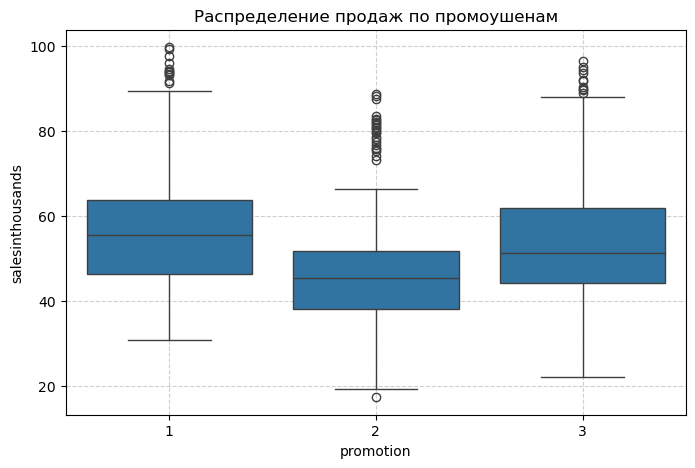

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='promotion', y='salesinthousands')
plt.title('Распределение продаж по промоушенам')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
import pandas as pd
from scipy.stats import mannwhitneyu
from itertools import combinations

# Задаем базовый уровень значимости
alpha = 0.05
promos = df['promotion'].unique()
pairs = list(combinations(promos, 2))

# Применяем поправку Бонферрони
alpha_corrected = alpha / len(pairs)

results = []
for p1, p2 in pairs:
    group1 = df[df['promotion'] == p1]['salesinthousands']
    group2 = df[df['promotion'] == p2]['salesinthousands']
    
    # Двусторонний тест Манна-Уитни
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')
    
    results.append({
        'Сравнение': f'{p1} vs {p2}',
        'p-value': p_val,
        'Стат. значимо': p_val < alpha_corrected
    })

results_df = pd.DataFrame(results)

print(f"Базовый alpha: {alpha}")
print(f"Скорректированный alpha (Бонферрони): {alpha_corrected:.4f}\n")
print(results_df)

Базовый alpha: 0.05
Скорректированный alpha (Бонферрони): 0.0167

  Сравнение       p-value  Стат. значимо
0    3 vs 2  1.197008e-07           True
1    3 vs 1  3.508410e-02          False
2    2 vs 1  5.845935e-12           True


либо первый, либо третий промоушен должен быть выбран, второй значительно отстает